# 📊 Quant Finance Cheat Sheet — Interactive Notebook

> *"The edge in markets is mathematical. The compounding is disciplined. The outcome is freedom."*

This notebook covers every concept from the **Quant Finance Cheat Sheet** with live examples using real stock data via `yfinance`.

**Sections**
1. Statistics
2. Risk Metrics
3. Portfolio Theory
4. Derivatives
5. Quant Trading
6. Probability & Stochastics
7. Hedge Fund Concepts
8. Quant Interview Terms
9. The Final Rule

## ⚙️ Setup

In [1]:
# !pip install yfinance pandas numpy matplotlib scipy statsmodels arch scikit-learn
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.stats as stats
import yfinance as yf
from datetime import datetime, timedelta

plt.rcParams.update({
    "figure.facecolor": "#0d1117", "axes.facecolor": "#161b22",
    "axes.edgecolor": "#30363d", "axes.labelcolor": "#c9d1d9",
    "xtick.color": "#8b949e", "ytick.color": "#8b949e",
    "text.color": "#c9d1d9", "grid.color": "#21262d",
    "grid.linestyle": "--", "grid.alpha": 0.5,
    "lines.linewidth": 1.8, "font.family": "monospace",
})
ACCENT = ["#58a6ff","#3fb950","#f78166","#d2a8ff","#ffa657","#79c0ff"]
print("Libraries loaded ✓")


Libraries loaded ✓


In [2]:
TICKERS = ["AAPL","MSFT","GOOGL","AMZN","SPY"]
END   = datetime.today()
START = END - timedelta(days=3*365)
print(f"Downloading {TICKERS} ...")
raw    = yf.download(TICKERS, start=START, end=END, auto_adjust=True, progress=False)
prices = raw["Close"].dropna()
returns = prices.pct_change().dropna()
log_ret = np.log(prices / prices.shift(1)).dropna()
print("Shape:", prices.shape)
prices.tail(3)


Shape: (750, 5)


Ticker,AAPL,AMZN,GOOGL,MSFT,SPY
Date,,,,,
2026-06-11,295.630005,241.509995,357.769989,390.339996,737.760010
2026-06-12,291.130005,238.550003,359.679993,390.739990,741.750000
2026-06-16,297.420013,246.839996,370.695007,393.204987,752.710022


---
## 1. 📐 Statistics
Core measures of return distributions: **mean, standard deviation, variance, correlation, covariance, skewness, kurtosis**.


In [ ]:
aapl = returns["AAPL"]
print("=== AAPL Daily Return Statistics ===")
print(f"  Mean (μ)              : {aapl.mean():.6f}  ({aapl.mean()*252:.2%} annualised)")
print(f"  Std Dev (σ)           : {aapl.std():.6f}  ({aapl.std()*np.sqrt(252):.2%} annualised vol)")
print(f"  Variance (σ²)         : {aapl.var():.8f}")
print(f"  Skewness              : {aapl.skew():.4f}")
print(f"  Kurtosis (excess)     : {aapl.kurt():.4f} ({'fat tails!' if aapl.kurt()>3 else 'near-normal'})")

=== AAPL Daily Return Statistics ===
  Mean (μ)              : 0.000786  (19.81% annualised)
  Std Dev (σ)           : 0.016406  (26.04% annualised vol)
  Variance (σ²)         : 0.00026917
  Skewness              : 0.7512
  Kurtosis (excess)     : 12.5073 (fat tails!)


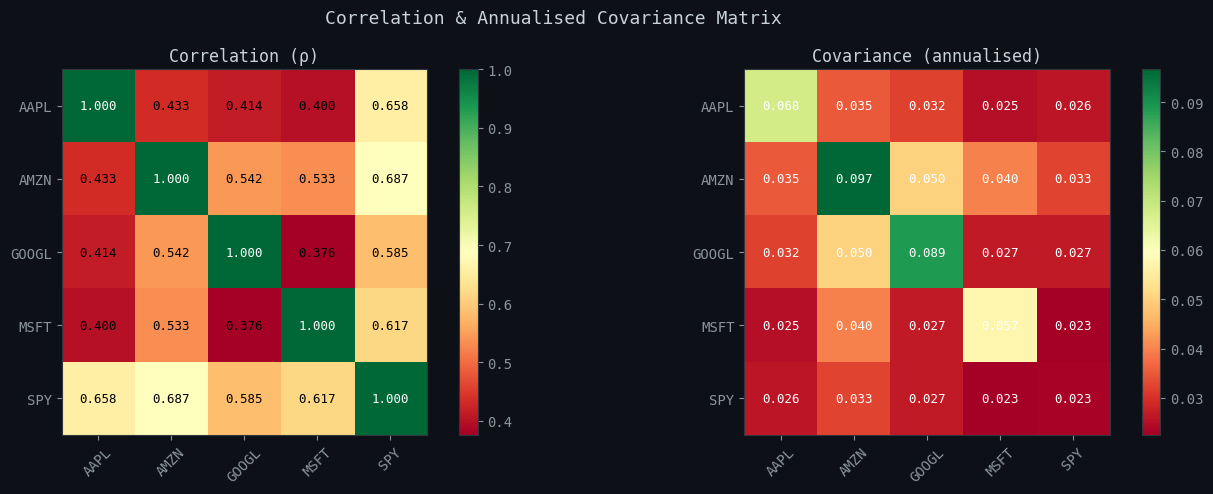

In [4]:
# Correlation & Covariance heatmaps
corr = returns.corr()
cov  = returns.cov() * 252

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Correlation & Annualised Covariance Matrix", color="#c9d1d9", fontsize=13)
for ax, data, title in zip(axes, [corr, cov], ["Correlation (ρ)", "Covariance (annualised)"]):
    im = ax.imshow(data, cmap="RdYlGn", vmin=data.values.min(), vmax=data.values.max())
    ax.set_xticks(range(len(data.columns))); ax.set_xticklabels(data.columns, rotation=45)
    ax.set_yticks(range(len(data.index)));  ax.set_yticklabels(data.index)
    ax.set_title(title, color="#c9d1d9")
    for i in range(len(data)):
        for j in range(len(data.columns)):
            ax.text(j, i, f"{data.iloc[i,j]:.3f}", ha="center", va="center", fontsize=9,
                    color="black" if 0.3 < data.iloc[i,j] < 0.9 else "white")
    plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()


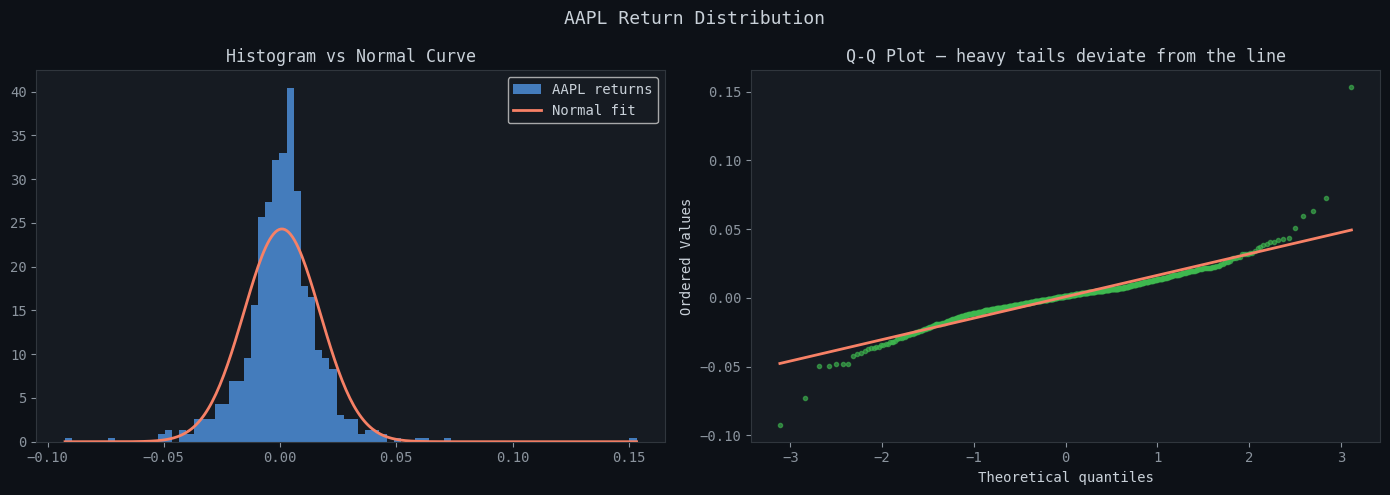

Jarque-Bera p-value: 0.00e+00  — p<0.05 means returns are NOT normally distributed


In [5]:
# Return distribution: histogram, normal fit, Q-Q plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("AAPL Return Distribution", color="#c9d1d9", fontsize=13)

ax = axes[0]
x = np.linspace(aapl.min(), aapl.max(), 300)
ax.hist(aapl, bins=80, density=True, color=ACCENT[0], alpha=0.7, label="AAPL returns")
ax.plot(x, stats.norm.pdf(x, aapl.mean(), aapl.std()), color=ACCENT[2], lw=2, label="Normal fit")
ax.set_title("Histogram vs Normal Curve"); ax.legend()

ax = axes[1]
stats.probplot(aapl, dist="norm", plot=ax)
ax.set_title("Q-Q Plot — heavy tails deviate from the line")
ax.get_lines()[0].set(color=ACCENT[1], markersize=3, alpha=0.6)
ax.get_lines()[1].set(color=ACCENT[2], lw=2)
plt.tight_layout(); plt.show()

p_jb = stats.jarque_bera(aapl).pvalue
print(f"Jarque-Bera p-value: {p_jb:.2e}  — p<0.05 means returns are NOT normally distributed")


---
## 2. 🛡️ Risk Metrics
**Sharpe, Sortino, Max Drawdown, VaR, Expected Shortfall, Beta**

In [6]:
RF_DAILY = 0.05 / 252

rows = []
spy_r = returns["SPY"]
for tk in TICKERS:
    r = returns[tk]
    excess = r - RF_DAILY
    sharpe  = excess.mean() / excess.std() * np.sqrt(252)
    neg_ex  = excess[excess < 0]
    sortino = excess.mean() / neg_ex.std() * np.sqrt(252)
    beta    = r.cov(spy_r) / spy_r.var()
    rows.append({"Ticker": tk, "Ann.Return": r.mean()*252,
                 "Ann.Vol": r.std()*np.sqrt(252),
                 "Sharpe": sharpe, "Sortino": sortino, "Beta": beta})

df_risk = pd.DataFrame(rows).set_index("Ticker")
print(df_risk.to_string(float_format="{:.3f}".format))


        Ann.Return  Ann.Vol  Sharpe  Sortino  Beta
Ticker                                            
AAPL         0.198    0.260   0.569    0.801 1.124
MSFT         0.087    0.239   0.156    0.212 0.968
GOOGL        0.418    0.298   1.236    1.852 1.142
AMZN         0.275    0.311   0.724    1.105 1.400
SPY          0.206    0.152   1.024    1.350 1.000


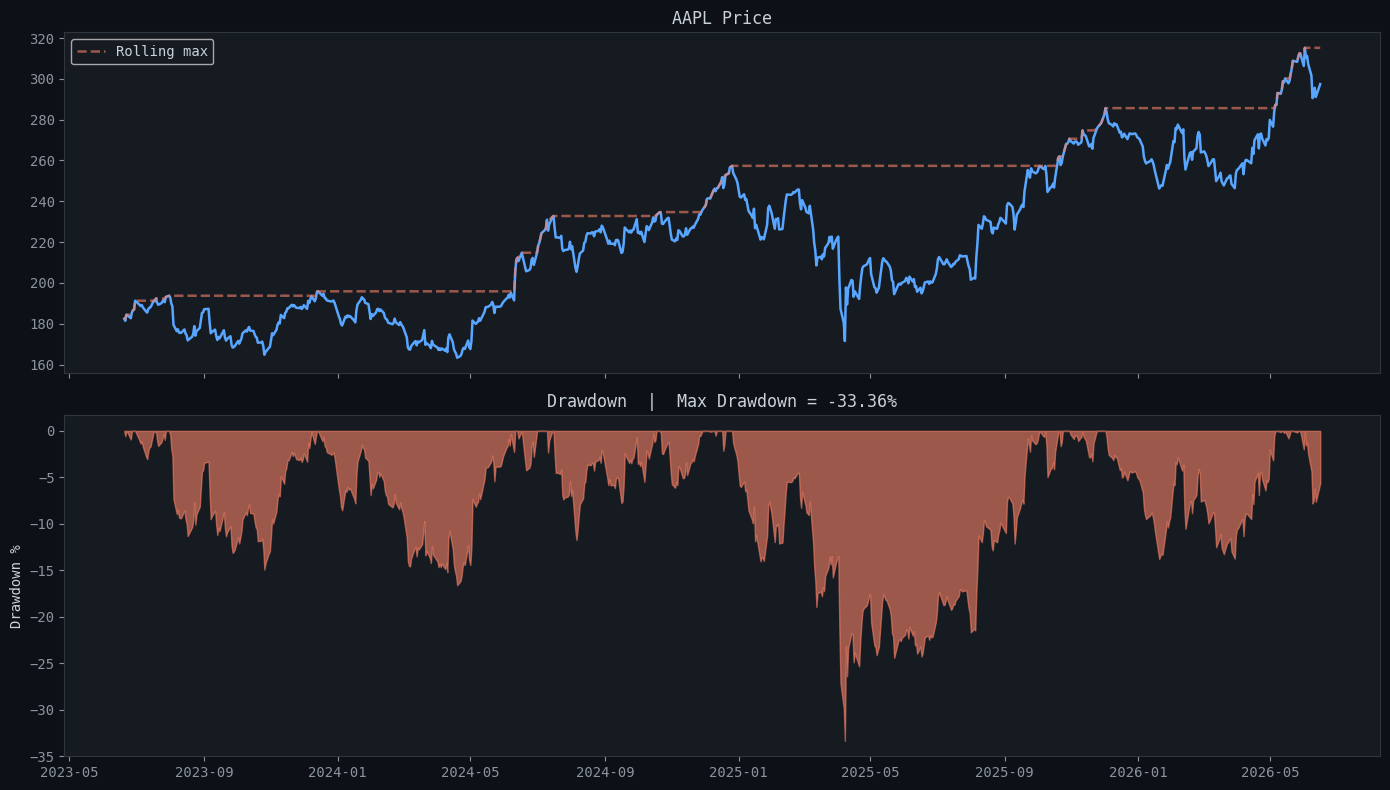

In [7]:
# Maximum Drawdown
p = prices["AAPL"]
roll_max = p.cummax()
drawdown = (p - roll_max) / roll_max
max_dd   = drawdown.min()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(p.index, p, color=ACCENT[0])
axes[0].plot(p.index, roll_max, color=ACCENT[2], linestyle="--", alpha=0.6, label="Rolling max")
axes[0].set_title("AAPL Price"); axes[0].legend()
axes[1].fill_between(drawdown.index, drawdown*100, 0, color=ACCENT[2], alpha=0.6)
axes[1].set_title(f"Drawdown  |  Max Drawdown = {max_dd:.2%}"); axes[1].set_ylabel("Drawdown %")
plt.tight_layout(); plt.show()


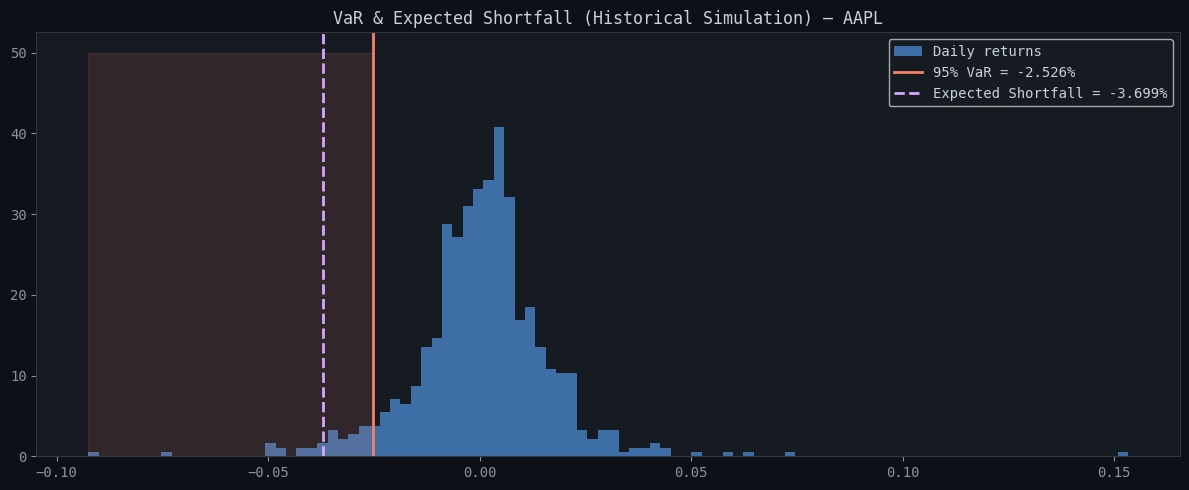

95% Historical VaR: -2.526%  — on 1 in 20 days, you lose at least this much
Expected Shortfall: -3.699%  — average loss in the worst 5% of days


In [8]:
# VaR and Expected Shortfall
alpha = 0.05
hist_var = aapl.quantile(alpha)
cvar     = aapl[aapl <= hist_var].mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(aapl, bins=100, density=True, color=ACCENT[0], alpha=0.6, label="Daily returns")
ax.axvline(hist_var, color=ACCENT[2], lw=2, label=f"95% VaR = {hist_var:.3%}")
ax.axvline(cvar,     color=ACCENT[3], lw=2, linestyle="--", label=f"Expected Shortfall = {cvar:.3%}")
ax.fill_betweenx([0, 50], aapl.min(), hist_var, color=ACCENT[2], alpha=0.12)
ax.set_title("VaR & Expected Shortfall (Historical Simulation) — AAPL", color="#c9d1d9")
ax.legend(); plt.tight_layout(); plt.show()

print(f"95% Historical VaR: {hist_var:.3%}  — on 1 in 20 days, you lose at least this much")
print(f"Expected Shortfall: {cvar:.3%}  — average loss in the worst 5% of days")


---
## 3. 💼 Portfolio Theory
**Diversification, Efficient Frontier, CAPM, Alpha, Portfolio Optimisation**

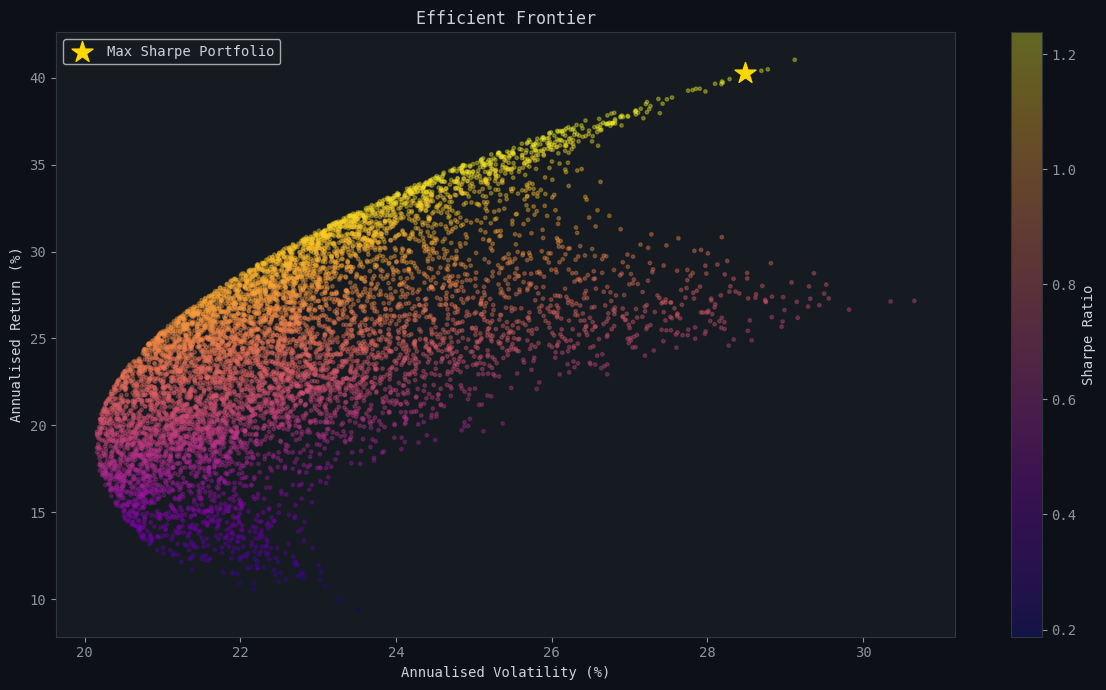

Max-Sharpe Weights:
  AAPL: 3.59%
  MSFT: 0.18%
  GOOGL: 91.18%
  AMZN: 5.05%


In [11]:
# Efficient Frontier via Monte Carlo
assets = [t for t in TICKERS if t != "SPY"]
mu_v   = returns[assets].mean() * 252
cov_m  = returns[assets].cov()  * 252

np.random.seed(42)
port_r, port_v, port_s, port_w = [], [], [], []
for _ in range(8000):
    w = np.random.dirichlet(np.ones(len(assets)))
    r = w @ mu_v.values
    v = np.sqrt(w @ cov_m.values @ w)
    port_r.append(r)
    port_v.append(v)
    port_s.append((r-0.05)/v)
    port_w.append(w)

port_r, port_v, port_s = map(np.array, [port_r, port_v, port_s])
best = np.argmax(port_s)

fig, ax = plt.subplots(figsize=(12, 7))
sc = ax.scatter(port_v*100, port_r*100, c=port_s, cmap="plasma", alpha=0.35, s=6)
ax.scatter(port_v[best]*100, port_r[best]*100, color="#ffd700", s=250, marker="*",
           zorder=6, label="Max Sharpe Portfolio")
plt.colorbar(sc, ax=ax, label="Sharpe Ratio")
ax.set_xlabel("Annualised Volatility (%)"); ax.set_ylabel("Annualised Return (%)")
ax.set_title("Efficient Frontier", color="#c9d1d9"); ax.legend()
plt.tight_layout(); plt.show()

print("Max-Sharpe Weights:")
for t, w in zip(assets, port_w[best]):
    print(f"  {t}: {w:.2%}")


In [12]:
# CAPM: E(R) = Rf + beta * (Rm - Rf)
RF = 0.05
MKT = returns["SPY"].mean() * 252
print("=== CAPM Expected Returns ===")
for tk in assets:
    beta_c = returns[tk].cov(returns["SPY"]) / returns["SPY"].var()
    e_r    = RF + beta_c * (MKT - RF)
    actual = returns[tk].mean() * 252
    alpha  = actual - e_r
    print(f"  {tk:5s}  β={beta_c:.2f}  E(R)={e_r:.2%}  Actual={actual:.2%}  α={alpha:+.2%}")


=== CAPM Expected Returns ===
  AAPL   β=1.12  E(R)=22.54%  Actual=19.81%  α=-2.73%
  MSFT   β=0.97  E(R)=20.11%  Actual=8.74%  α=-11.37%
  GOOGL  β=1.14  E(R)=22.83%  Actual=41.83%  α=+19.00%
  AMZN   β=1.40  E(R)=26.86%  Actual=27.50%  α=+0.65%


---
## 4. 📄 Derivatives — Black-Scholes & The Greeks

In [13]:
from scipy.stats import norm as N_dist

def bs_price(S, K, T, r, sigma, opt="call"):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if opt == "call":
        return S*N_dist.cdf(d1) - K*np.exp(-r*T)*N_dist.cdf(d2)
    return K*np.exp(-r*T)*N_dist.cdf(-d2) - S*N_dist.cdf(-d1)

def greeks(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    delta_c = N_dist.cdf(d1)
    gamma   = N_dist.pdf(d1) / (S * sigma * np.sqrt(T))
    theta_c = (-S*N_dist.pdf(d1)*sigma/(2*np.sqrt(T)) - r*K*np.exp(-r*T)*N_dist.cdf(d2)) / 365
    vega    = S * N_dist.pdf(d1) * np.sqrt(T) / 100
    return {"Delta(call)": delta_c, "Delta(put)": delta_c-1,
            "Gamma": gamma, "Theta/day": theta_c, "Vega/1%vol": vega}

S0    = float(prices["AAPL"].iloc[-1])
K0    = round(S0 / 10) * 10
T0    = 30/365
r0    = 0.05
sig0  = float(aapl.std() * np.sqrt(252))

print(f"AAPL  S=${S0:.2f}  K=${K0}  T=30d  r={r0:.0%}  σ={sig0:.2%}")
print(f"  Call Price : ${bs_price(S0,K0,T0,r0,sig0,'call'):.4f}")
print(f"  Put  Price : ${bs_price(S0,K0,T0,r0,sig0,'put'):.4f}")
print()
for k, v in greeks(S0, K0, T0, r0, sig0).items():
    print(f"  {k:15s}: {v:.6f}")


AAPL  S=$297.42  K=$300  T=30d  r=5%  σ=26.04%
  Call Price : $8.2190
  Put  Price : $9.5687

  Delta(call)    : 0.490704
  Delta(put)     : -0.509296
  Gamma          : 0.017959
  Theta/day      : -0.166485
  Vega/1%vol     : 0.340076


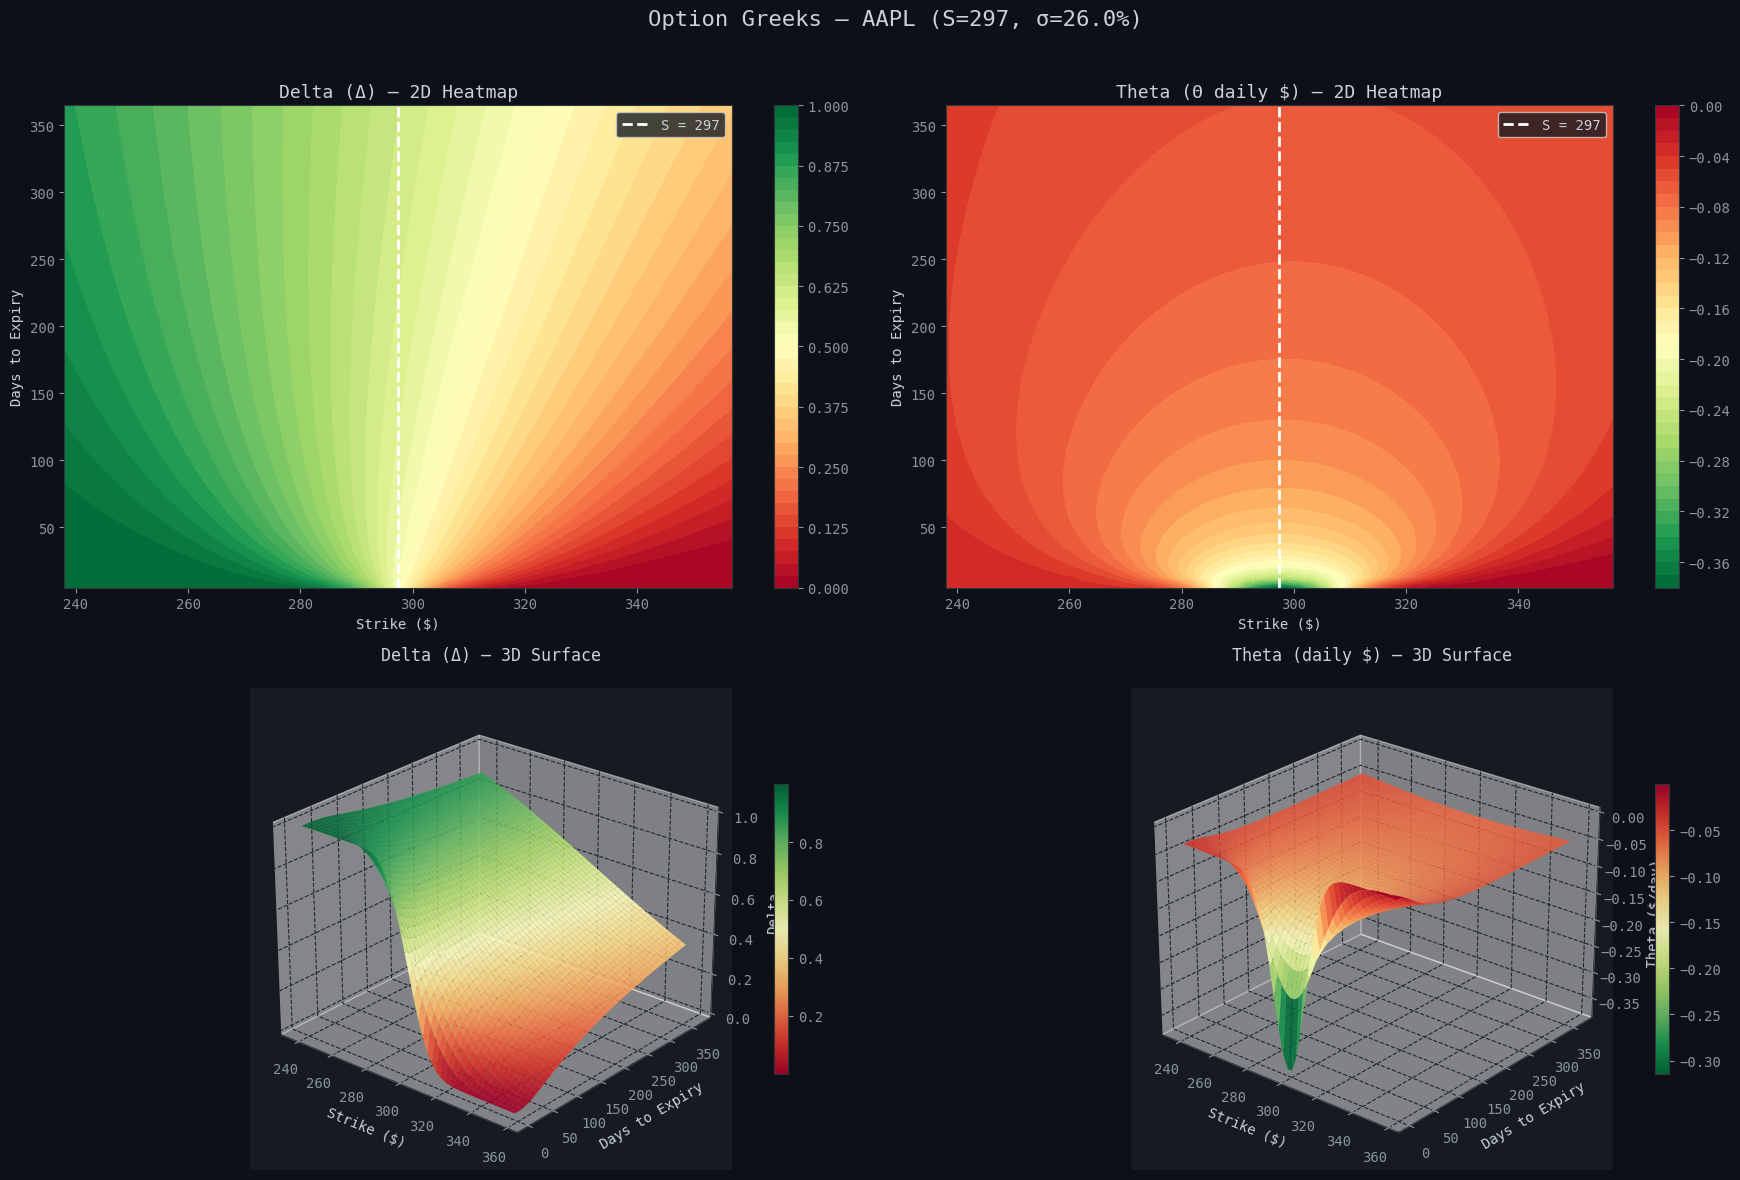

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ====================== Data Preparation ======================
strikes    = np.linspace(S0*0.8, S0*1.2, 50)
maturities = np.linspace(5/365, 1, 50)
KK, TT = np.meshgrid(strikes, maturities)

DELTA = np.vectorize(lambda k,t: greeks(S0, k, t, r0, sig0)["Delta(call)"])(KK, TT)
THETA = np.vectorize(lambda k,t: greeks(S0, k, t, r0, sig0)["Theta/day"])(KK, TT)

# ====================== 2x2 Plot ======================
fig = plt.figure(figsize=(18, 12))
fig.suptitle(f"Option Greeks — AAPL (S={S0:.0f}, σ={sig0:.1%})", 
             fontsize=16, color="#c9d1d9")

# Top-left: 2D Delta
ax1 = fig.add_subplot(2, 2, 1)
im1 = ax1.contourf(KK, TT*365, DELTA, levels=40, cmap='RdYlGn')
ax1.axvline(S0, color="white", lw=2, linestyle="--", label=f"S = {S0:.0f}")
fig.colorbar(im1, ax=ax1)
ax1.set_title("Delta (Δ) — 2D Heatmap", fontsize=13)
ax1.set_xlabel("Strike ($)")
ax1.set_ylabel("Days to Expiry")
ax1.legend()

# Top-right: 2D Theta
ax2 = fig.add_subplot(2, 2, 2)
im2 = ax2.contourf(KK, TT*365, THETA, levels=40, cmap='RdYlGn_r')
ax2.axvline(S0, color="white", lw=2, linestyle="--", label=f"S = {S0:.0f}")
fig.colorbar(im2, ax=ax2)
ax2.set_title("Theta (Θ daily $) — 2D Heatmap", fontsize=13)
ax2.set_xlabel("Strike ($)")
ax2.set_ylabel("Days to Expiry")
ax2.legend()

# Bottom-left: 3D Delta
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
surf1 = ax3.plot_surface(KK, TT*365, DELTA, cmap='RdYlGn', 
                        linewidth=0, antialiased=True, alpha=0.9)
ax3.set_xlabel('Strike ($)')
ax3.set_ylabel('Days to Expiry')
ax3.set_zlabel('Delta')
ax3.set_title("Delta (Δ) — 3D Surface", pad=20)
fig.colorbar(surf1, ax=ax3, shrink=0.6, aspect=20)
ax3.view_init(elev=25, azim=-50)

# Bottom-right: 3D Theta
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
surf2 = ax4.plot_surface(KK, TT*365, THETA, cmap='RdYlGn_r', 
                        linewidth=0, antialiased=True, alpha=0.9)
ax4.set_xlabel('Strike ($)')
ax4.set_ylabel('Days to Expiry')
ax4.set_zlabel('Theta ($/day)')
ax4.set_title("Theta (daily $) — 3D Surface", pad=20)
fig.colorbar(surf2, ax=ax4, shrink=0.6, aspect=20)
ax4.view_init(elev=25, azim=-50)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for suptitle
plt.show()

---
## 5. 🤖 Quant Trading Strategies

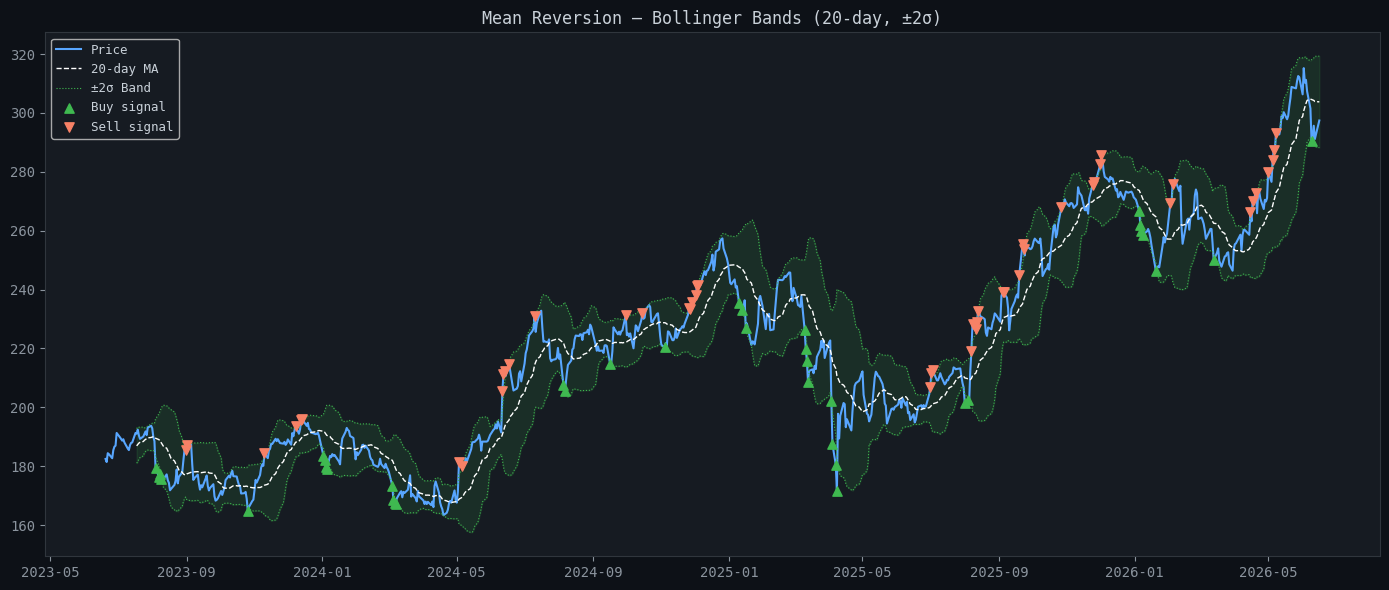

In [ ]:
# Mean Reversion — Bollinger Bands
p = prices["AAPL"].copy()
ma20 = p.rolling(20).mean()
std20 = p.rolling(20).std()
upper = ma20 + 2*std20
lower = ma20 - 2*std20

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(p.index, p, color=ACCENT[0], lw=1.5, label="Price")
ax.plot(p.index, ma20, color="white", lw=1, linestyle="--", label="20-day MA")
ax.fill_between(p.index, lower, upper, alpha=0.12, color=ACCENT[1])
ax.plot(p.index, upper, color=ACCENT[1], lw=0.8, linestyle=":")
ax.plot(p.index, lower, color=ACCENT[1], lw=0.8, linestyle=":", label="±2σ Band")
ax.scatter(p[p < lower].index, p[p < lower], color=ACCENT[1], marker="^", s=45, zorder=5, label="Buy signal")
ax.scatter(p[p > upper].index, p[p > upper], color=ACCENT[2], marker="v", s=45, zorder=5, label="Sell signal")
ax.set_title("Mean Reversion — Bollinger Bands (20-day, ±2σ)", color="#c9d1d9")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()


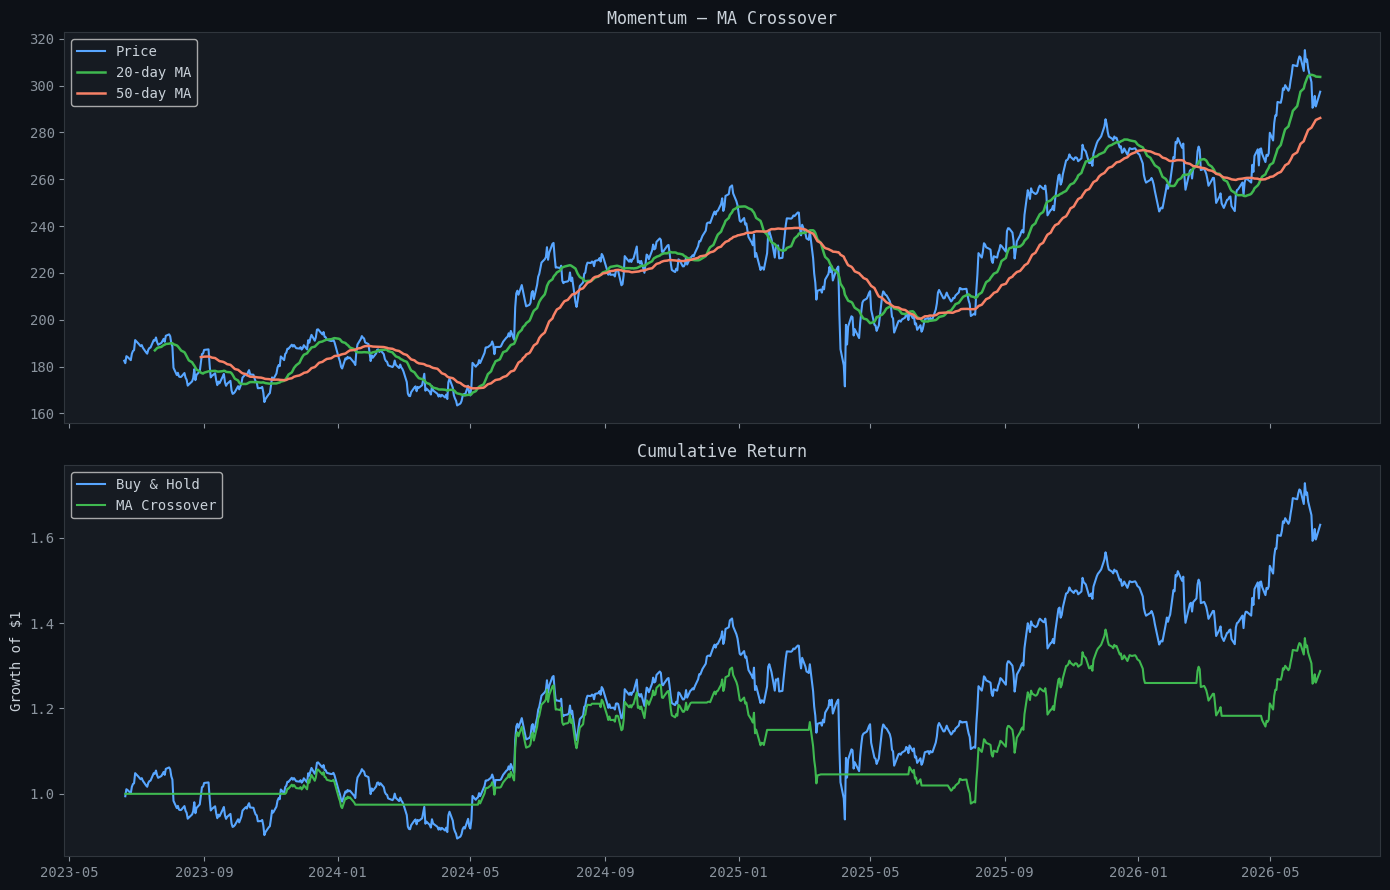

Buy & Hold: 63.01%  |  MA Crossover: 28.77%


In [18]:
# Momentum — Dual MA Crossover
fast, slow = 20, 50
p2 = prices["AAPL"].copy()
sig = (p2.rolling(fast).mean() > p2.rolling(slow).mean()).astype(int).shift(1)
strat_r = sig * returns["AAPL"]
cum_bh  = (1 + returns["AAPL"].dropna()).cumprod()
cum_st  = (1 + strat_r.dropna()).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
axes[0].plot(p2.index, p2, color=ACCENT[0], label="Price", lw=1.5)
axes[0].plot(p2.index, p2.rolling(fast).mean(), color=ACCENT[1], label=f"{fast}-day MA")
axes[0].plot(p2.index, p2.rolling(slow).mean(), color=ACCENT[2], label=f"{slow}-day MA")
axes[0].set_title("Momentum — MA Crossover"); axes[0].legend()
axes[1].plot(cum_bh.index, cum_bh,   color=ACCENT[0], lw=1.5, label="Buy & Hold")
axes[1].plot(cum_st.index, cum_st,   color=ACCENT[1], lw=1.5, label="MA Crossover")
axes[1].set_title("Cumulative Return"); axes[1].legend(); axes[1].set_ylabel("Growth of $1")
plt.tight_layout(); plt.show()
print(f"Buy & Hold: {cum_bh.iloc[-1]-1:.2%}  |  MA Crossover: {cum_st.iloc[-1]-1:.2%}")


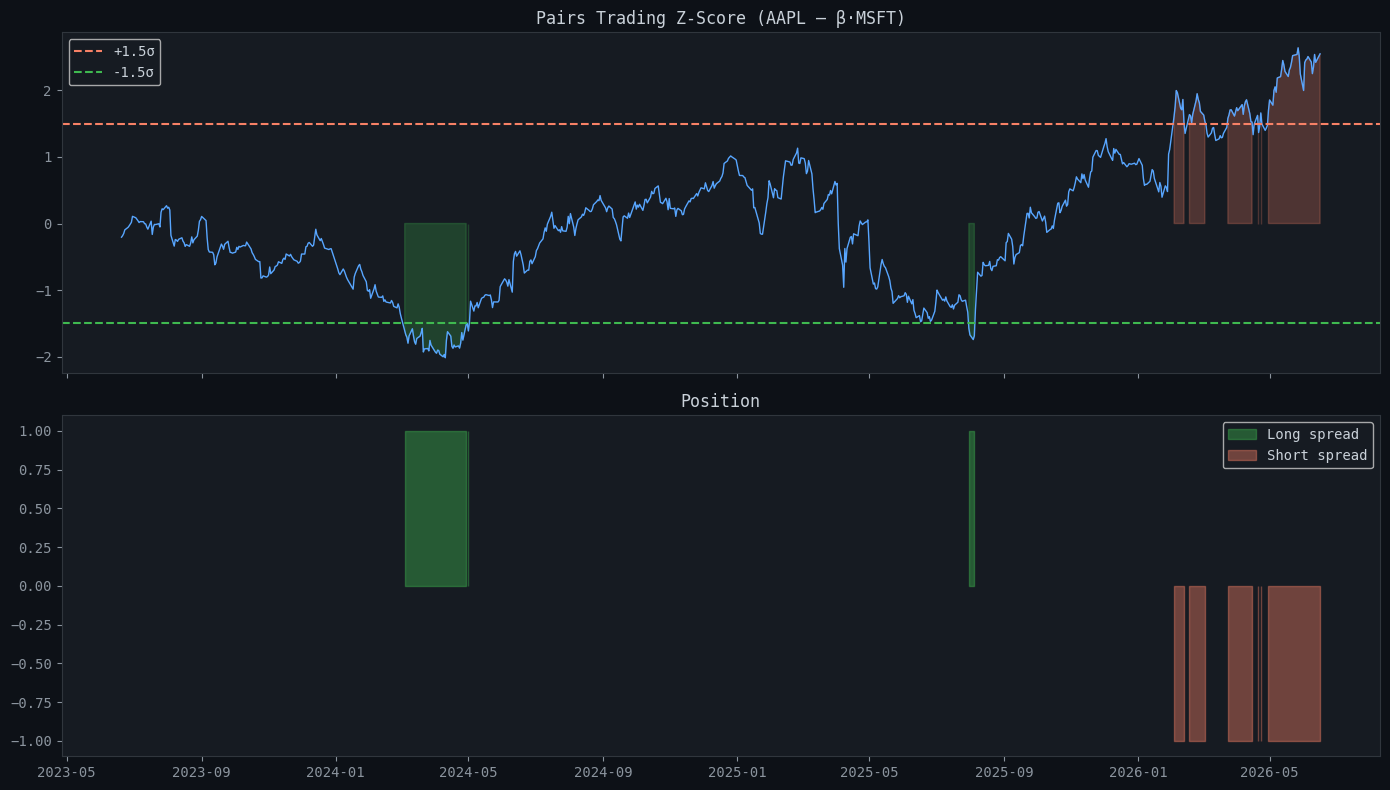

Hedge ratio β=0.6585  |  Cointegration p-value=0.9745
p < 0.05 → cointegrated pair → mean reversion is statistically justified


In [20]:
# Statistical Arbitrage — Pairs Trading (AAPL / MSFT)
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint

y_p = np.log(prices["AAPL"]); x_p = np.log(prices["MSFT"])
ols_p = sm.OLS(y_p, sm.add_constant(x_p)).fit()
hedge_r = ols_p.params.iloc[1]
spread  = y_p - hedge_r * x_p - ols_p.params.iloc[0]
z_score = (spread - spread.mean()) / spread.std()

ENTRY, EXIT_Z = 1.5, 0.5
pos = pd.Series(0.0, index=z_score.index)
pos[z_score < -ENTRY] =  1.0
pos[z_score >  ENTRY] = -1.0
pos[(z_score.abs() < EXIT_Z)] = 0.0
pos = pos.ffill()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(z_score.index, z_score, color=ACCENT[0], lw=1)
for level, col, lbl in [( ENTRY, ACCENT[2], f"+{ENTRY}σ"), (-ENTRY, ACCENT[1], f"-{ENTRY}σ")]:
    axes[0].axhline(level, color=col, linestyle="--", lw=1.5, label=lbl)
axes[0].fill_between(z_score.index, z_score, 0, where=(z_score < -ENTRY), color=ACCENT[1], alpha=0.25)
axes[0].fill_between(z_score.index, z_score, 0, where=(z_score >  ENTRY), color=ACCENT[2], alpha=0.25)
axes[0].set_title("Pairs Trading Z-Score (AAPL – β·MSFT)"); axes[0].legend()
axes[1].fill_between(pos.index, pos, 0, where=(pos>0), color=ACCENT[1], alpha=0.4, label="Long spread")
axes[1].fill_between(pos.index, pos, 0, where=(pos<0), color=ACCENT[2], alpha=0.4, label="Short spread")
axes[1].set_title("Position"); axes[1].legend()
plt.tight_layout(); plt.show()

coint_p = coint(y_p, x_p)[1]
print(f"Hedge ratio β={hedge_r:.4f}  |  Cointegration p-value={coint_p:.4f}")
print("p < 0.05 → cointegrated pair → mean reversion is statistically justified")


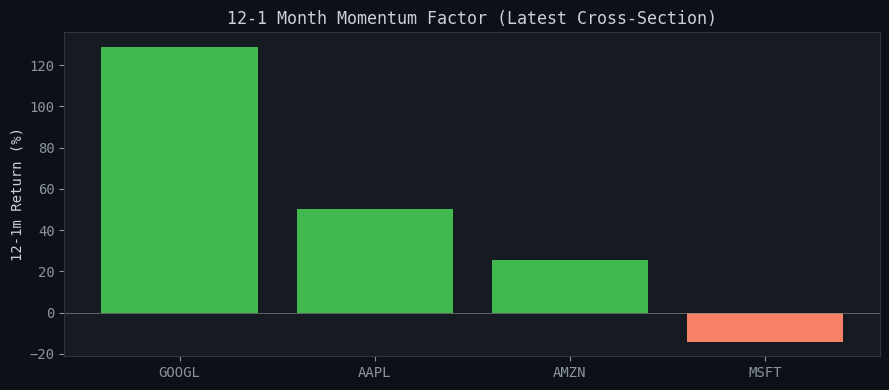

Factor investing: go long high-momentum, short low-momentum assets


In [21]:
# Factor Investing — Momentum Factor
mom = prices.pct_change(252 - 21).shift(21)
last = mom.iloc[-1].drop("SPY").sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
cols = [ACCENT[1] if v >= 0 else ACCENT[2] for v in last.values]
ax.bar(last.index, last.values*100, color=cols)
ax.set_title("12-1 Month Momentum Factor (Latest Cross-Section)", color="#c9d1d9")
ax.set_ylabel("12-1m Return (%)"); ax.axhline(0, color="gray", lw=0.5)
plt.tight_layout(); plt.show()
print("Factor investing: go long high-momentum, short low-momentum assets")


---
## 6. 🎲 Probability & Stochastics

In [22]:
# Expected Value
print("=== Expected Value ===")
outcomes = [("Up 5%", 0.50, 0.05), ("Down 3%", 0.35, -0.03), ("Flat", 0.15, 0.0)]
ev = sum(p*v for _, p, v in outcomes)
for name, p, v in outcomes:
    print(f"  {name:10s}  P={p:.0%}  V={v:+.0%}  contribution={p*v:+.5f}")
print(f"  EV = {ev:.5f} = {ev:.3%}")

print()
print("=== Bayes Theorem: P(Recession | Yield Curve Inverts) ===")
P_B_given_A = 0.85; P_A = 0.20; P_B = 0.30
posterior = (P_B_given_A * P_A) / P_B
print(f"  Prior P(Recession)          = {P_A:.0%}")
print(f"  P(Inversion | Recession)    = {P_B_given_A:.0%}")
print(f"  P(Inversion) marginal       = {P_B:.0%}")
print(f"  Posterior P(Recession|Inv.) = {posterior:.1%}")


=== Expected Value ===
  Up 5%       P=50%  V=+5%  contribution=+0.02500
  Down 3%     P=35%  V=-3%  contribution=-0.01050
  Flat        P=15%  V=+0%  contribution=+0.00000
  EV = 0.01450 = 1.450%

=== Bayes Theorem: P(Recession | Yield Curve Inverts) ===
  Prior P(Recession)          = 20%
  P(Inversion | Recession)    = 85%
  P(Inversion) marginal       = 30%
  Posterior P(Recession|Inv.) = 56.7%


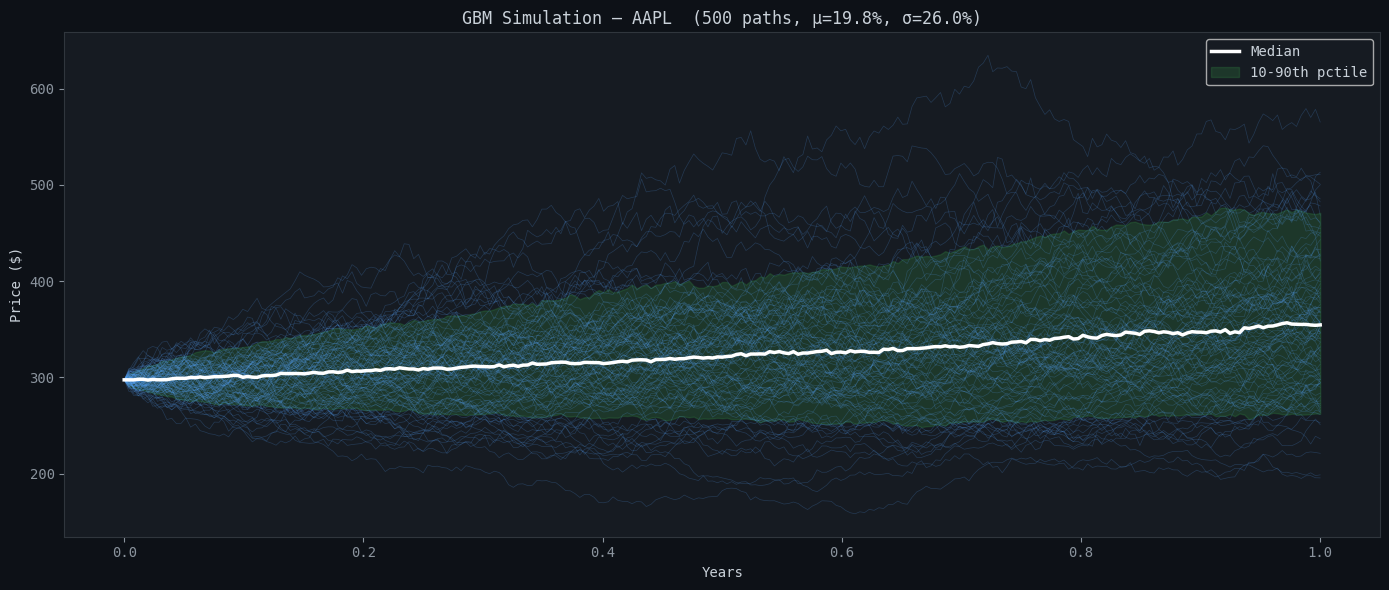

Start: $297.42  |  Median end: $354.47  |  5th pct: $244.03  |  95th pct: $503.25


In [23]:
# Geometric Brownian Motion Simulation
S0_g  = float(prices["AAPL"].iloc[-1])
mu_g  = float(aapl.mean() * 252)
sig_g = float(aapl.std()  * np.sqrt(252))
T_g, N_g, M_g = 1.0, 252, 500
dt = T_g / N_g
np.random.seed(0)

dW = np.random.normal(0, np.sqrt(dt), (N_g, M_g))
S_paths = np.zeros((N_g+1, M_g)); S_paths[0] = S0_g
for t in range(1, N_g+1):
    S_paths[t] = S_paths[t-1] * np.exp((mu_g - 0.5*sig_g**2)*dt + sig_g*dW[t-1])

t_ax = np.linspace(0, T_g, N_g+1)
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(t_ax, S_paths[:, :100], lw=0.5, alpha=0.22, color=ACCENT[0])
ax.plot(t_ax, np.median(S_paths, axis=1), color="white", lw=2.5, label="Median")
ax.fill_between(t_ax, np.percentile(S_paths,10,axis=1), np.percentile(S_paths,90,axis=1),
                alpha=0.18, color=ACCENT[1], label="10-90th pctile")
ax.set_title(f"GBM Simulation — AAPL  ({M_g} paths, μ={mu_g:.1%}, σ={sig_g:.1%})", color="#c9d1d9")
ax.set_xlabel("Years"); ax.set_ylabel("Price ($)"); ax.legend()
plt.tight_layout(); plt.show()

final_p = S_paths[-1]
print(f"Start: ${S0_g:.2f}  |  Median end: ${np.median(final_p):.2f}  "
      f"|  5th pct: ${np.percentile(final_p,5):.2f}  |  95th pct: ${np.percentile(final_p,95):.2f}")


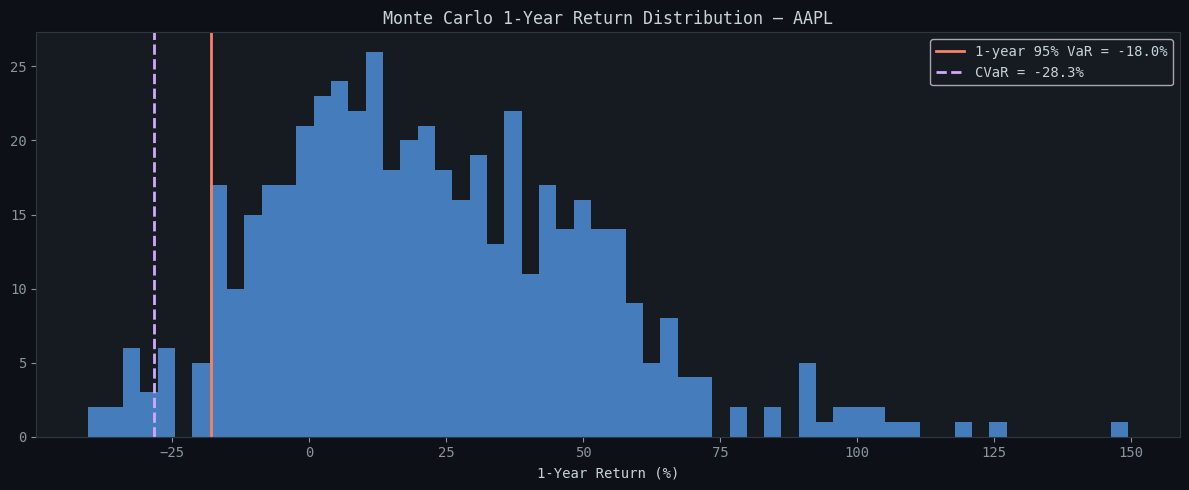

In [24]:
# Monte Carlo VaR
mc_ret  = (final_p / S0_g) - 1
mc_var  = np.percentile(mc_ret, 5)
mc_cvar = mc_ret[mc_ret <= mc_var].mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(mc_ret*100, bins=60, color=ACCENT[0], alpha=0.7)
ax.axvline(mc_var*100,  color=ACCENT[2], lw=2, label=f"1-year 95% VaR = {mc_var:.1%}")
ax.axvline(mc_cvar*100, color=ACCENT[3], lw=2, linestyle="--", label=f"CVaR = {mc_cvar:.1%}")
ax.set_title("Monte Carlo 1-Year Return Distribution — AAPL", color="#c9d1d9")
ax.set_xlabel("1-Year Return (%)"); ax.legend()
plt.tight_layout(); plt.show()


---
## 7. 🏦 Hedge Fund Concepts

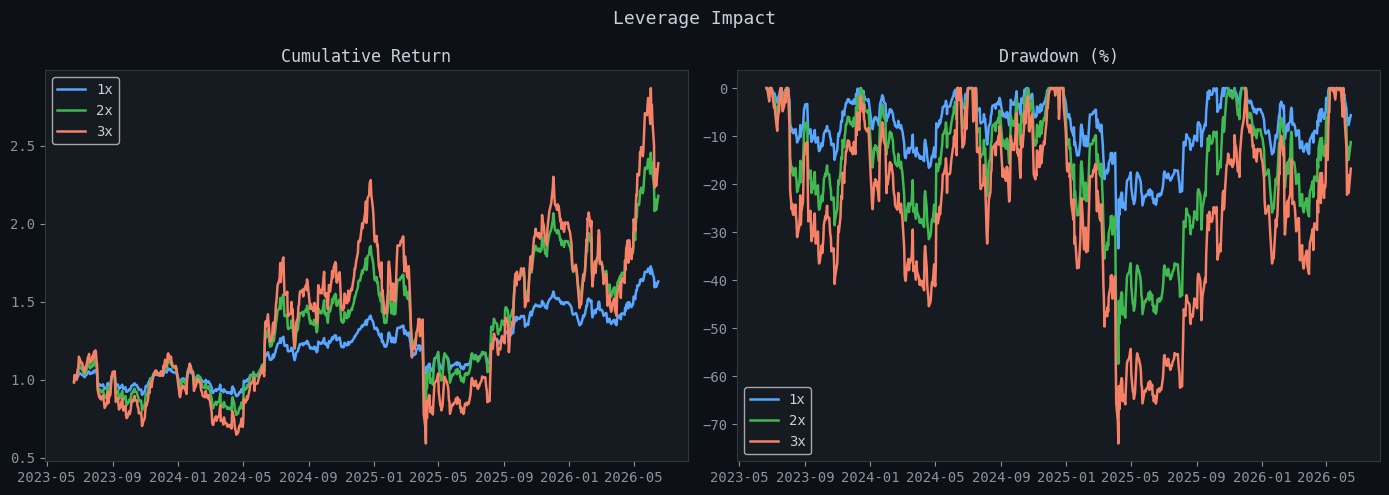

Leverage multiplies both gains and drawdowns — risk management is critical


In [25]:
# Leverage: amplifies returns AND losses
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Leverage Impact", color="#c9d1d9", fontsize=13)

for lev, col in zip([1, 2, 3], ACCENT[:3]):
    r_l = returns["AAPL"] * lev
    cum = (1 + r_l).cumprod()
    dd  = (cum - cum.cummax()) / cum.cummax()
    axes[0].plot(cum.index, cum,    color=col, label=f"{lev}x")
    axes[1].plot(dd.index,  dd*100, color=col, label=f"{lev}x")

for ax, t in zip(axes, ["Cumulative Return", "Drawdown (%)"]):
    ax.set_title(t); ax.legend()
plt.tight_layout(); plt.show()
print("Leverage multiplies both gains and drawdowns — risk management is critical")


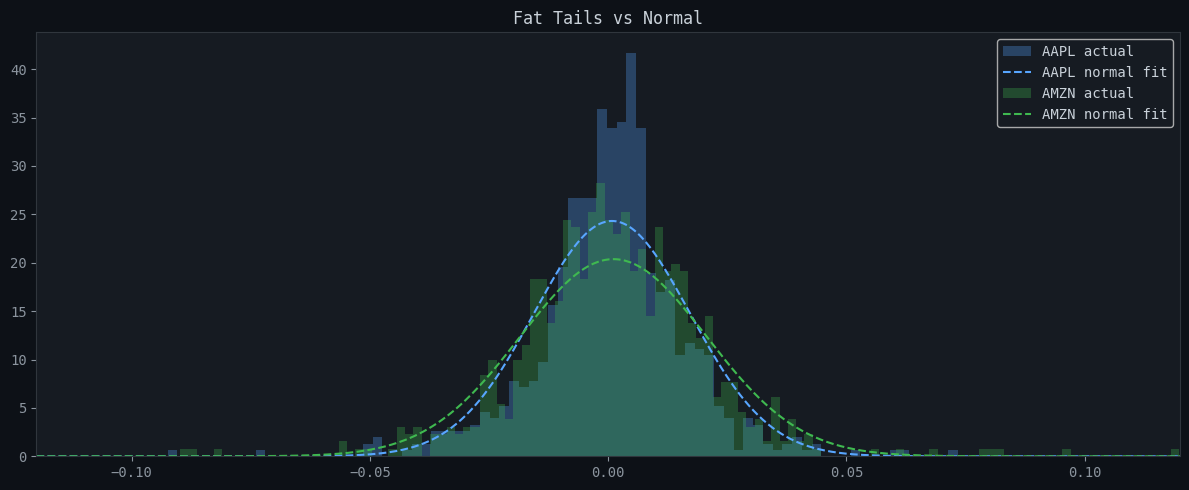

AAPL: kurtosis=12.51  tail events>3σ=1.20%  (normal theory: 0.27%)
AMZN: kurtosis=4.50  tail events>3σ=1.34%  (normal theory: 0.27%)
SPY: kurtosis=21.55  tail events>3σ=1.07%  (normal theory: 0.27%)


In [26]:
# Fat Tails: actual vs theoretical
fig, ax = plt.subplots(figsize=(12, 5))
x_range = np.linspace(-0.12, 0.12, 500)
for tk, col in zip(["AAPL", "AMZN"], ACCENT[:2]):
    r = returns[tk]
    ax.hist(r, bins=120, density=True, alpha=0.3, color=col, label=f"{tk} actual")
    ax.plot(x_range, stats.norm.pdf(x_range, r.mean(), r.std()),
            color=col, lw=1.5, linestyle="--", label=f"{tk} normal fit")

ax.set_xlim(-0.12, 0.12); ax.set_title("Fat Tails vs Normal", color="#c9d1d9"); ax.legend()
plt.tight_layout(); plt.show()

for tk in ["AAPL", "AMZN", "SPY"]:
    r = returns[tk]
    tail = (r.abs() > 3*r.std()).sum() / len(r)
    print(f"{tk}: kurtosis={r.kurt():.2f}  tail events>3σ={tail:.2%}  (normal theory: 0.27%)")


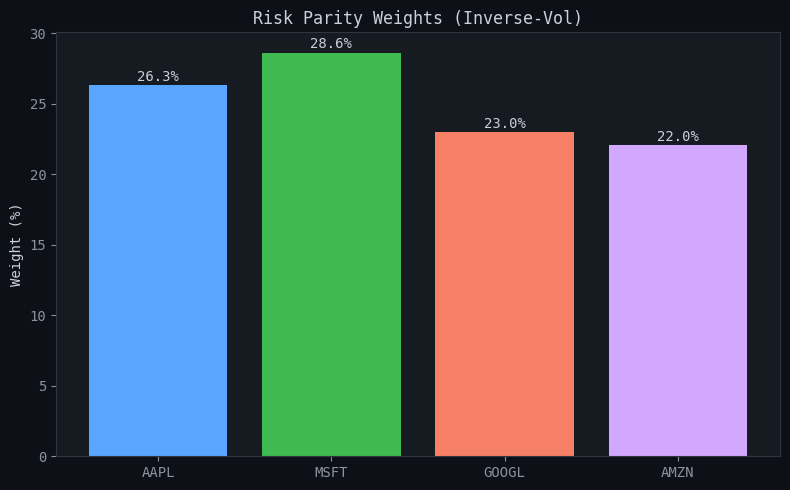

In [27]:
# Risk Parity (inverse-volatility weighting)
vols_rp = returns[assets].std() * np.sqrt(252)
w_rp    = (1/vols_rp) / (1/vols_rp).sum()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(assets, w_rp*100, color=ACCENT[:len(assets)])
for bar, w in zip(bars, w_rp):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"{w:.1%}", ha="center", fontsize=10, color="#c9d1d9")
ax.set_title("Risk Parity Weights (Inverse-Vol)", color="#c9d1d9"); ax.set_ylabel("Weight (%)")
plt.tight_layout(); plt.show()


---
## 8. 📚 Quant Interview Terms

In [28]:
# Stationarity (ADF test) + ARIMA
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

adf_stat, adf_p = adfuller(aapl)[:2]
print(f"ADF on AAPL returns: stat={adf_stat:.4f}  p={adf_p:.4f}")
print("Stationary ✓" if adf_p < 0.05 else "Non-stationary!")

model_arima = ARIMA(aapl, order=(1, 0, 1)).fit()
print()
print(model_arima.summary().tables[1])


ADF on AAPL returns: stat=-13.4635  p=0.0000
Stationary ✓

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0008      0.001      1.200      0.230      -0.000       0.002
ar.L1          0.0156      0.572      0.027      0.978      -1.106       1.137
ma.L1          0.0273      0.572      0.048      0.962      -1.093       1.148
sigma2         0.0003   5.73e-06     46.811      0.000       0.000       0.000


/Users/kevintanyuejun/opt/anaconda3/envs/llm_ai_modelling/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/kevintanyuejun/opt/anaconda3/envs/llm_ai_modelling/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/kevintanyuejun/opt/anaconda3/envs/llm_ai_modelling/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


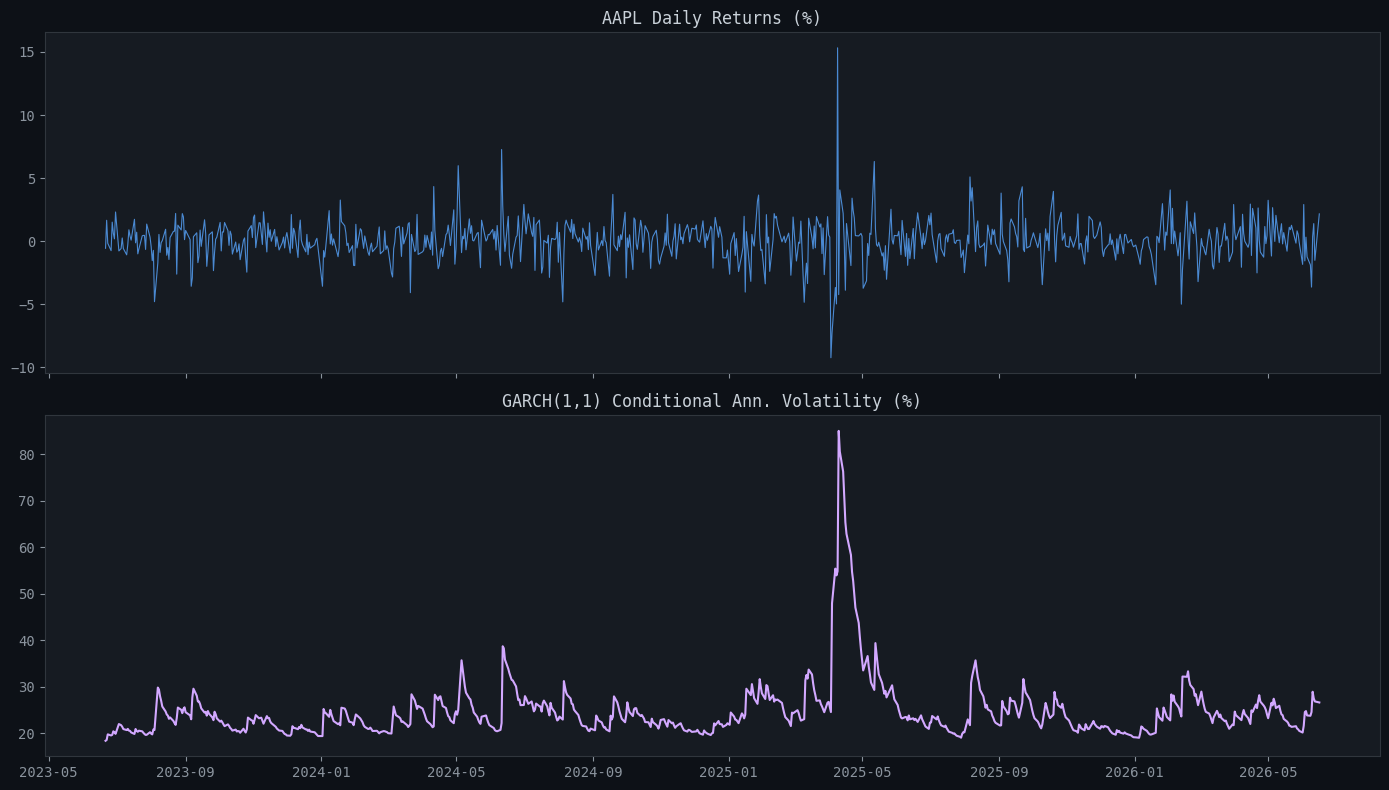

Volatility clusters: calm periods followed by turbulent periods


In [ ]:
# GARCH(1,1) — volatility clustering
try:
    from arch import arch_model
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable,"-m","pip","install","arch","-q","--break-system-packages"])
    from arch import arch_model

garch_m = arch_model(aapl*100, vol="Garch", p=1, q=1, dist="normal")
garch_r = garch_m.fit(disp="off")
cond_v  = garch_r.conditional_volatility / 100

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(aapl.index, aapl*100, color=ACCENT[0], lw=0.8, alpha=0.8)
axes[0].set_title("AAPL Daily Returns (%)")
axes[1].plot(cond_v.index, cond_v*np.sqrt(252)*100, color=ACCENT[3], lw=1.5)
axes[1].set_title("GARCH(1,1) Conditional Ann. Volatility (%)")
plt.tight_layout(); plt.show()
print("Volatility clusters: calm periods followed by turbulent periods")


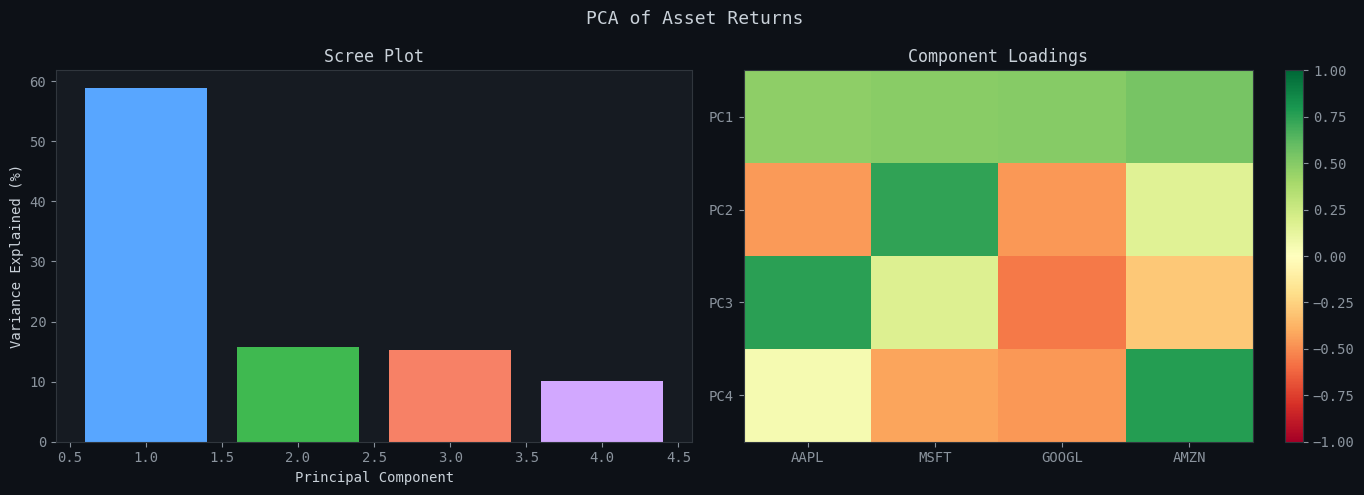

PC1 explains 58.9% of variance — this is the 'market factor'


In [30]:
# PCA — Principal Components of Asset Returns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_pca = StandardScaler().fit_transform(returns[assets])
pca   = PCA().fit(X_pca)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("PCA of Asset Returns", color="#c9d1d9", fontsize=13)
axes[0].bar(range(1, len(assets)+1), pca.explained_variance_ratio_*100, color=ACCENT[:len(assets)])
axes[0].set_xlabel("Principal Component"); axes[0].set_ylabel("Variance Explained (%)")
axes[0].set_title("Scree Plot")

im = axes[1].imshow(pca.components_, cmap="RdYlGn", aspect="auto", vmin=-1, vmax=1)
axes[1].set_xticks(range(len(assets))); axes[1].set_xticklabels(assets)
axes[1].set_yticks(range(len(assets))); axes[1].set_yticklabels([f"PC{i+1}" for i in range(len(assets))])
axes[1].set_title("Component Loadings"); plt.colorbar(im, ax=axes[1])
plt.tight_layout(); plt.show()
print(f"PC1 explains {pca.explained_variance_ratio_[0]:.1%} of variance — this is the 'market factor'")


In [31]:
# OLS Regression + Walk-Forward Cross-Validation
import statsmodels.api as sm

ols = sm.OLS(returns["AAPL"], sm.add_constant(returns["SPY"])).fit()
print("=== OLS: AAPL ~ const + SPY ===")
print(f"  Alpha (α): {ols.params.iloc[0]:.6f}  Beta (β): {ols.params.iloc[1]:.4f}")
print(f"  R-squared: {ols.rsquared:.4f}")
print()

print("=== Walk-Forward CV ===")
n = len(aapl); fold = n // 6
for i in range(5):
    tr = aapl.iloc[:fold*(i+1)]; te = aapl.iloc[fold*(i+1):fold*(i+2)]
    mse = ((te - tr.mean())**2).mean()
    print(f"  Fold {i+1}: train={len(tr):4d}  test={len(te):4d}  MSE={mse:.2e}")
print()
print("Walk-forward avoids look-ahead bias — train on past, test on future only")


=== OLS: AAPL ~ const + SPY ===
  Alpha (α): -0.000133  Beta (β): 1.1235
  R-squared: 0.4327

=== Walk-Forward CV ===
  Fold 1: train= 124  test= 124  MSE=2.28e-04
  Fold 2: train= 248  test= 124  MSE=1.75e-04
  Fold 3: train= 372  test= 124  MSE=6.57e-04
  Fold 4: train= 496  test= 124  MSE=1.97e-04
  Fold 5: train= 620  test= 124  MSE=2.04e-04

Walk-forward avoids look-ahead bias — train on past, test on future only


---
## 9. 🎯 The Final Rule — Full Dashboard

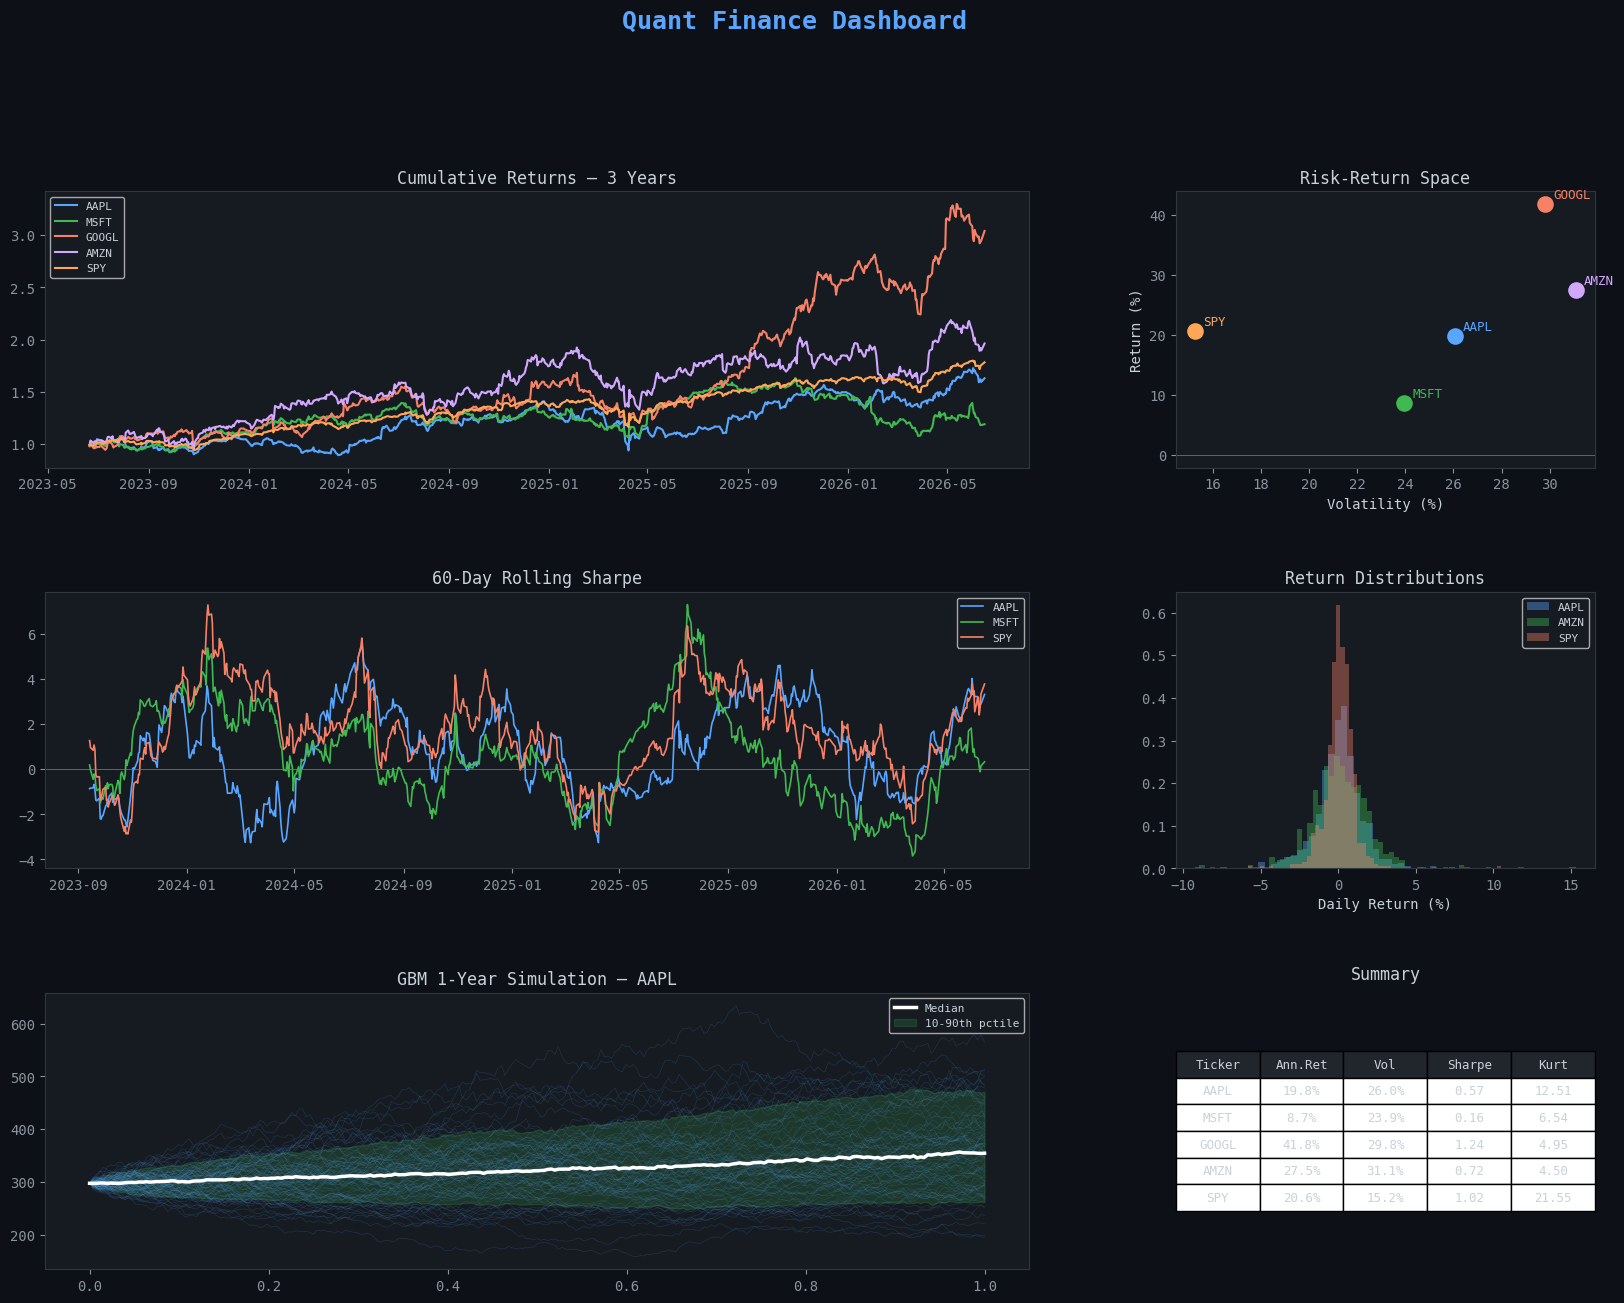

In [33]:
# Full Quant Dashboard
fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor("#0d1117")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# Panel 1: Cumulative returns
ax1 = fig.add_subplot(gs[0, :2])
for tk, col in zip(TICKERS, ACCENT):
    ax1.plot((1+returns[tk]).cumprod().index,
             (1+returns[tk]).cumprod(), color=col, lw=1.5, label=tk)
ax1.set_title("Cumulative Returns — 3 Years", color="#c9d1d9"); ax1.legend(fontsize=8)

# Panel 2: Risk-return scatter
ax2 = fig.add_subplot(gs[0, 2])
for tk, col in zip(TICKERS, ACCENT):
    r_a = returns[tk].mean()*252; v_a = returns[tk].std()*np.sqrt(252)
    ax2.scatter(v_a*100, r_a*100, color=col, s=120, zorder=5)
    ax2.annotate(tk, (v_a*100, r_a*100), xytext=(6,4), textcoords="offset points",
                 fontsize=9, color=col)
ax2.set_xlabel("Volatility (%)"); ax2.set_ylabel("Return (%)")
ax2.set_title("Risk-Return Space", color="#c9d1d9"); ax2.axhline(0, color="gray", lw=0.5)

# Panel 3: Rolling Sharpe
ax3 = fig.add_subplot(gs[1, :2])
for tk, col in zip(["AAPL","MSFT","SPY"], ACCENT[:3]):
    rs = (returns[tk].rolling(60).mean()/returns[tk].rolling(60).std())*np.sqrt(252)
    ax3.plot(rs.index, rs, color=col, lw=1.2, label=tk)
ax3.axhline(0, color="gray", lw=0.5)
ax3.set_title("60-Day Rolling Sharpe", color="#c9d1d9"); ax3.legend(fontsize=8)

# Panel 4: Return distributions
ax4 = fig.add_subplot(gs[1, 2])
for tk, col in zip(["AAPL","AMZN","SPY"], ACCENT[:3]):
    ax4.hist(returns[tk]*100, bins=60, density=True, alpha=0.4, color=col, label=tk)
ax4.set_title("Return Distributions", color="#c9d1d9"); ax4.set_xlabel("Daily Return (%)")
ax4.legend(fontsize=8)

# Panel 5: GBM
ax5 = fig.add_subplot(gs[2, :2])
ax5.plot(t_ax, S_paths[:,:80], lw=0.4, alpha=0.2, color=ACCENT[0])
ax5.plot(t_ax, np.median(S_paths,axis=1), color="white", lw=2.5, label="Median")
ax5.fill_between(t_ax, np.percentile(S_paths,10,axis=1),
                 np.percentile(S_paths,90,axis=1), alpha=0.18, color=ACCENT[1], label="10-90th pctile")
ax5.set_title("GBM 1-Year Simulation — AAPL", color="#c9d1d9"); ax5.legend(fontsize=8)

# Panel 6: Summary table
ax6 = fig.add_subplot(gs[2, 2]); ax6.axis("off")
tbl_data = [[tk, f"{returns[tk].mean()*252:.1%}", f"{returns[tk].std()*np.sqrt(252):.1%}",
             f"{(returns[tk].mean()-RF_DAILY)/returns[tk].std()*np.sqrt(252):.2f}",
             f"{returns[tk].kurt():.2f}"] for tk in TICKERS]
tbl = ax6.table(cellText=tbl_data, colLabels=["Ticker","Ann.Ret","Vol","Sharpe","Kurt"],
                cellLoc="center", loc="center", colColours=["#21262d"]*5)
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.6)
ax6.set_title("Summary", color="#c9d1d9", pad=10)

fig.suptitle("Quant Finance Dashboard", fontsize=18, color="#58a6ff", y=1.01, fontweight="bold")
# plt.savefig("/mnt/user-data/outputs/quant_dashboard.png", dpi=150,bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show(); 
# print("Dashboard saved ✓")


---
## 🏁 Final Takeaways

| Retail Investor asks... | Quant asks... |
|---|---|
| *"Will this trade work?"* | *"What is the probability distribution of outcomes?"* |

> **In finance, it's not about being right often. It's about managing risk and probabilities over the long run.**

```
Strong Math  +  Intuition  +  Programming  +  Domain Knowledge  =  Edge
```

### Key Lessons Recap
- **Statistics**: Understand your distribution before fitting any model.  
- **Risk Metrics**: Sharpe, Sortino, VaR, and Max Drawdown matter more than raw returns.  
- **Portfolio Theory**: Diversification genuinely reduces risk — until correlations spike in a crisis.  
- **Black-Scholes**: Great starting point; real markets have fat tails and vol smiles.  
- **Mean Reversion vs Momentum**: Both are real — they operate on different timescales.  
- **GBM/Monte Carlo**: Always look at the full distribution, never just the mean.  
- **Backtesting**: Easy to overfit — walk-forward CV is non-negotiable.  
- **Risk Parity**: Allocate risk equally, not capital equally.
